**下面的代码先通过不同的时序过程生成对应时间序列，然后可视化该时间序列的ACF和PACF图。在实际应用中，如果遇到类似的ACF与PACF图，即可应用其可能对应的时序过程模型进行拟合。**

### 1.AR 模型的 ACF 图与 PACF 图

AR(1) 模型的表达式为：
$$
(1-0.5L)y_t=1\cdot\varepsilon_t\ \ \Rightarrow \ \ y_t=0.5y_{t-1}+\varepsilon_t.
$$

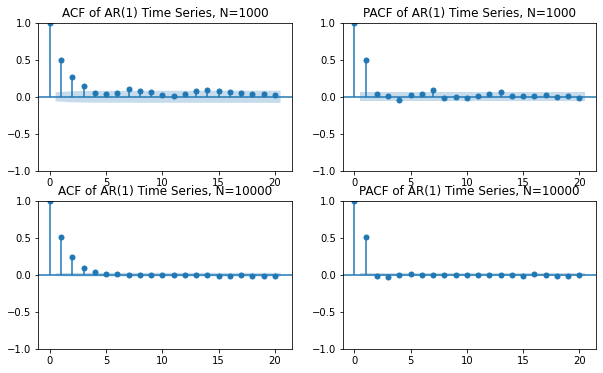

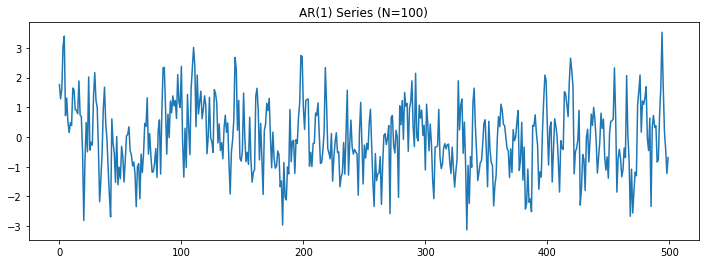

In [90]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm

# 设置随机种子以确保结果可重复
np.random.seed(0)

# 生成AR(1)时间序列数据
ar = np.array([1, -0.5])  # 我们将使用的AR模型的参数，对应(18)式中等号左边的滞后算子的系数
ma = np.array([1])  # 这是MA模型的参数，对应(18)式中等号右边的滞后算子的系数，在这个例子中我们不需要它，故将其设为1
n = [int(1000),   int(10_000)] # 我们将生成的数据点的数量

arma_process = sm.tsa.ArmaProcess(ar, ma)
y1 = arma_process.generate_sample(nsample=n[0])
y2 = arma_process.generate_sample(nsample=n[1])

fig, axes = plt.subplots(2, 2, figsize=(10, 6))  

# 绘制ACF图像
plot_acf(y1, lags=20, ax=axes[0,0])
axes[0,0].set_title('ACF of AR(1) Time Series, N=1000')

# 绘制PACF图像
plot_pacf(y1, lags=20, ax=axes[0,1])
axes[0,1].set_title('PACF of AR(1) Time Series, N=1000')

# 绘制ACF图像
plot_acf(y2, lags=20, ax=axes[1,0])
axes[1,0].set_title('ACF of AR(1) Time Series, N=10000')

# 绘制PACF图像
plot_pacf(y2, lags=20, ax=axes[1,1])
axes[1,1].set_title('PACF of AR(1) Time Series, N=10000')
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(y1[:500])
plt.title('AR(1) Series')
plt.show()

AR(2) 模型的表达式为：
$$
(1-0.5L-0.4L^2)y_t=1\cdot\varepsilon_t\ \ \Rightarrow \ \ y_t=0.5y_{t-1}+0.4y_{t-2}+\varepsilon_t.
$$

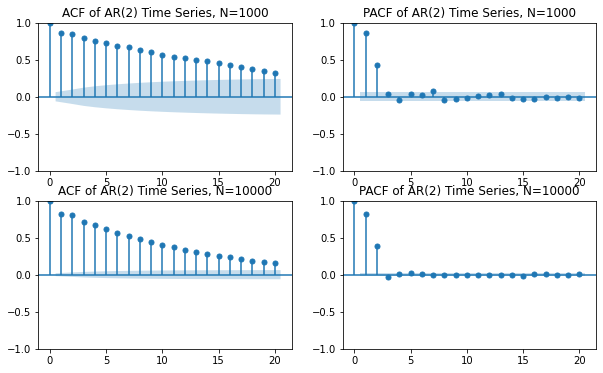

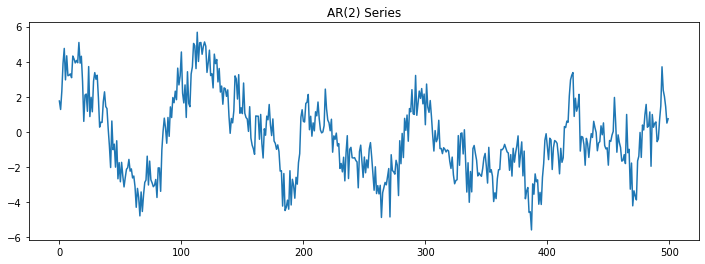

In [91]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm

# 设置随机种子以确保结果可重复
np.random.seed(0)

# 生成AR(1)时间序列数据
ar = np.array([1, -0.5, -0.4])  # 我们将使用的AR模型的参数，对应(18)式中等号左边的滞后算子的系数
ma = np.array([1])  # 这是MA模型的参数，对应(18)式中等号右边的滞后算子的系数，在这个例子中我们不需要它，故将其设为1
n = [int(1000),   int(10_000)] # 我们将生成的数据点的数量

arma_process = sm.tsa.ArmaProcess(ar, ma)
y1 = arma_process.generate_sample(nsample=n[0])
y2 = arma_process.generate_sample(nsample=n[1])

fig, axes = plt.subplots(2, 2, figsize=(10, 6)) 

# 绘制ACF图像
plot_acf(y1, lags=20, ax=axes[0,0])
axes[0,0].set_title('ACF of AR(2) Time Series, N=1000')

# 绘制PACF图像
plot_pacf(y1, lags=20, ax=axes[0,1])
axes[0,1].set_title('PACF of AR(2) Time Series, N=1000')

# 绘制ACF图像
plot_acf(y2, lags=20, ax=axes[1,0])
axes[1,0].set_title('ACF of AR(2) Time Series, N=10000')

# 绘制PACF图像
plot_pacf(y2, lags=20, ax=axes[1,1])
axes[1,1].set_title('PACF of AR(2) Time Series, N=10000')
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(y1[:500])
plt.title('AR(2) Series')
plt.show()

AR(p)模型的ACF图拖尾，而PACF图则是p阶截尾。

### 2.MA 模型的 ACF 图与 PACF 图

MA(1) 模型的表达式为：
$$
1\cdot y_t= (1+0.5L)\varepsilon_t\ \ \Rightarrow \ \ y_t=\varepsilon_t+0.5\varepsilon_{t-1}.
$$

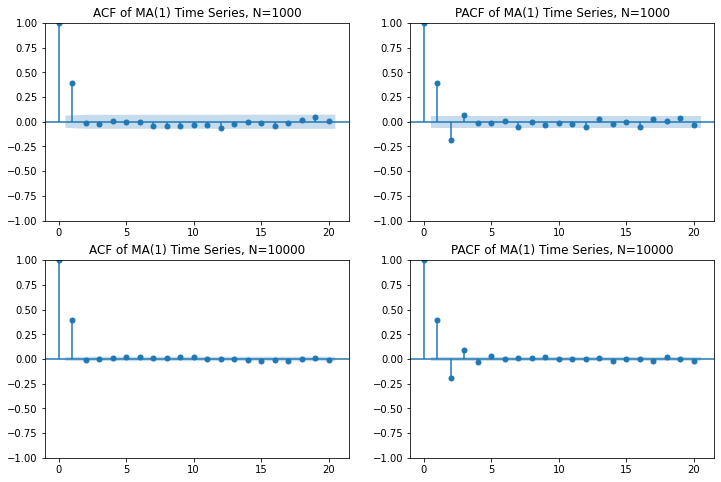

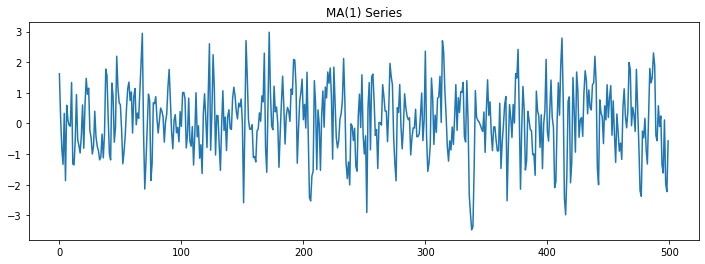

In [93]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

np.random.seed(1)

# 定义MA模型的参数
ar = np.array([1])
ma = np.array([1, 0.5])
n = [int(1000),   int(10_000)] # 我们将生成的数据点的数量

# 创建ARMA模型
arma_process = ArmaProcess(ar, ma)
sample1 = arma_process.generate_sample(nsample=n[0])
sample2 = arma_process.generate_sample(nsample=n[1])

# 绘制ACF和PACF图
plt.figure(figsize=(12,8))
plt.subplot(221)
plot_acf(sample1, ax=plt.gca(), lags=20)
plt.title('ACF of MA(1) Time Series, N=1000')
plt.subplot(222)
plot_pacf(sample1, ax=plt.gca(), lags=20)
plt.title('PACF of MA(1) Time Series, N=1000')
plt.subplot(223)
plot_acf(sample2, ax=plt.gca(), lags=20)
plt.title('ACF of MA(1) Time Series, N=10000')
plt.subplot(224)
plot_pacf(sample2, ax=plt.gca(), lags=20)
plt.title('PACF of MA(1) Time Series, N=10000')
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(sample1[:500])
plt.title('MA(1) Series')
plt.show()

MA(2) 模型的表达式为：
$$
1\cdot y_t= (1+0.5L+0.7L^2)\varepsilon_t\ \ \Rightarrow \ \ y_t=\varepsilon_t+0.5\varepsilon_{t-1}+0.7\varepsilon_{t-2}.
$$

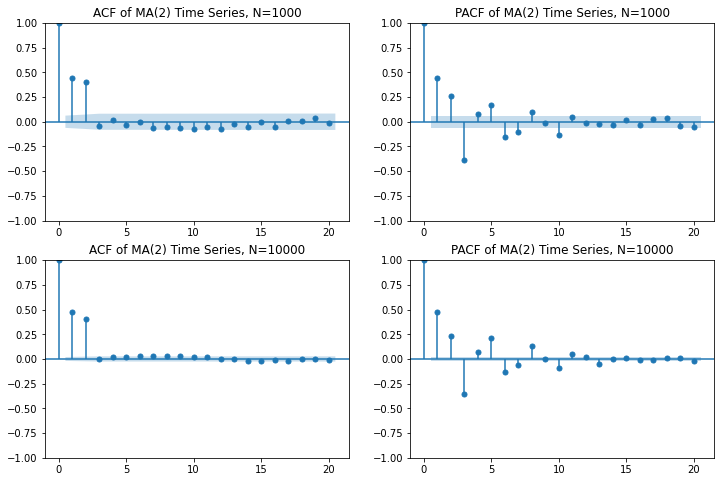

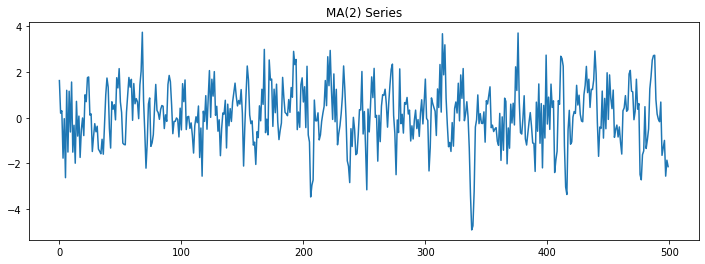

In [95]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

np.random.seed(1)

# 定义MA模型的参数
ar = np.array([1])
ma = np.array([1, 0.5, 0.7])
n = [int(1000),   int(10_000)] # 我们将生成的数据点的数量

# 创建ARMA模型
arma_process = ArmaProcess(ar, ma)
sample1 = arma_process.generate_sample(nsample=n[0])
sample2 = arma_process.generate_sample(nsample=n[1])

# 绘制ACF和PACF图
plt.figure(figsize=(12,8))
plt.subplot(221)
plot_acf(sample1, ax=plt.gca(), lags=20)
plt.title('ACF of MA(2) Time Series, N=1000')
plt.subplot(222)
plot_pacf(sample1, ax=plt.gca(), lags=20)
plt.title('PACF of MA(2) Time Series, N=1000')
plt.subplot(223)
plot_acf(sample2, ax=plt.gca(), lags=20)
plt.title('ACF of MA(2) Time Series, N=10000')
plt.subplot(224)
plot_pacf(sample2, ax=plt.gca(), lags=20)
plt.title('PACF of MA(2) Time Series, N=10000')
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(sample1[:500])
plt.title('MA(2) Series')
plt.show()

MA(q)模型的ACF图q阶截尾，而PACF图则是拖尾。

### 3.ARMA 模型的 ACF 图与 PACF 图

ARMA(1,1) 模型的表达式为：
$$
(1-0.5L) y_t= (1+0.5L)\varepsilon_t\ \ \Rightarrow \ \ y_t=0.5y_{t-1}+\varepsilon_t+0.5\varepsilon_{t-1}.
$$

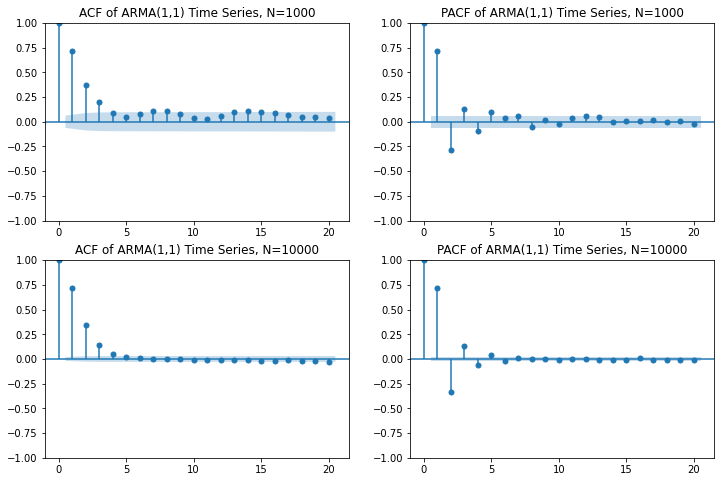

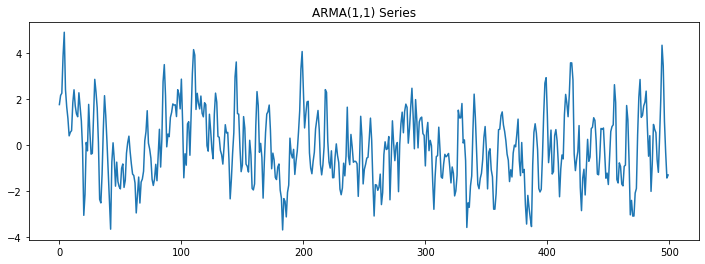

In [96]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm

# 设置随机种子以确保结果可重复
np.random.seed(0)

ar = np.array([1, -0.5]) 
ma = np.array([1, 0.5])  
n = [int(1000),   int(10_000)] 

arma_process = sm.tsa.ArmaProcess(ar, ma)
y1 = arma_process.generate_sample(nsample=n[0])
y2 = arma_process.generate_sample(nsample=n[1])

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 绘制ACF图像
plot_acf(y1, lags=20, ax=axes[0,0])
axes[0,0].set_title('ACF of ARMA(1,1) Time Series, N=1000')

# 绘制PACF图像
plot_pacf(y1, lags=20, ax=axes[0,1])
axes[0,1].set_title('PACF of ARMA(1,1) Time Series, N=1000')

# 绘制ACF图像
plot_acf(y2, lags=20, ax=axes[1,0])
axes[1,0].set_title('ACF of ARMA(1,1) Time Series, N=10000')

# 绘制PACF图像
plot_pacf(y2, lags=20, ax=axes[1,1])
axes[1,1].set_title('PACF of ARMA(1,1) Time Series, N=10000')
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(y1[:500])
plt.title('ARMA(1,1) Series')
plt.show()

ARMA(1,2) 模型的表达式为：
$$
(1-0.5L)\cdot y_t= (1+0.5L+0.7L^2)\varepsilon_t\ \ \Rightarrow \ \ y_t=0.5y_{t-1}+\varepsilon_t+0.5\varepsilon_{t-1}+0.7\varepsilon_{t-2}.
$$

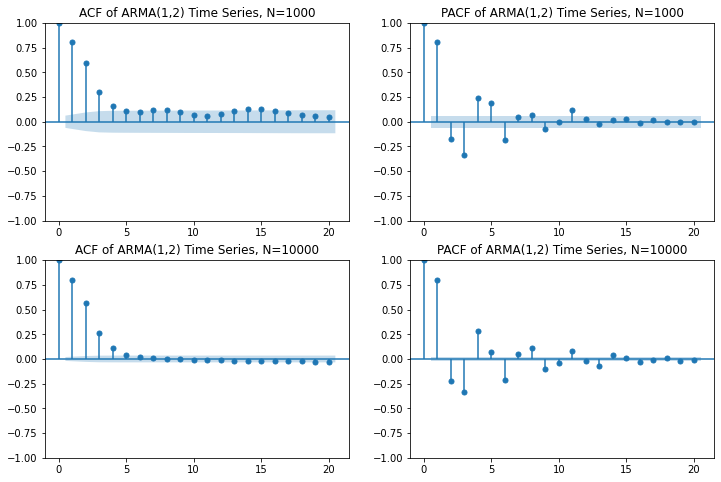

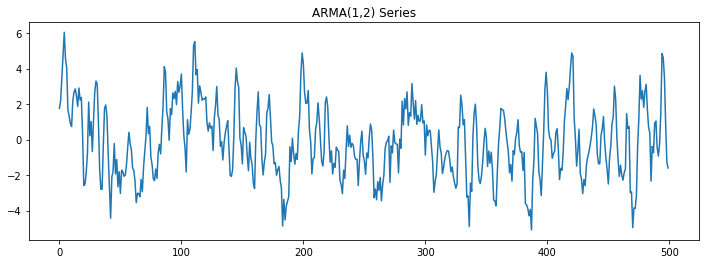

In [97]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm

# 设置随机种子以确保结果可重复
np.random.seed(0)

ar = np.array([1, -0.5]) 
ma = np.array([1, 0.5, 0.7])  
n = [int(1000),   int(10_000)] # 我们将生成的数据点的数量

arma_process = sm.tsa.ArmaProcess(ar, ma)
y1 = arma_process.generate_sample(nsample=n[0])
y2 = arma_process.generate_sample(nsample=n[1])

fig, axes = plt.subplots(2, 2, figsize=(12, 8))  

# 绘制ACF图像
plot_acf(y1, lags=20, ax=axes[0,0])
axes[0,0].set_title('ACF of ARMA(1,2) Time Series, N=1000')

# 绘制PACF图像
plot_pacf(y1, lags=20, ax=axes[0,1])
axes[0,1].set_title('PACF of ARMA(1,2) Time Series, N=1000')

# 绘制ACF图像
plot_acf(y2, lags=20, ax=axes[1,0])
axes[1,0].set_title('ACF of ARMA(1,2) Time Series, N=10000')

# 绘制PACF图像
plot_pacf(y2, lags=20, ax=axes[1,1])
axes[1,1].set_title('PACF of ARMA(1,2) Time Series, N=10000')
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(y1[:500])
plt.title('ARMA(1,2) Series')
plt.show()

ARMA(2,1) 模型的表达式为：
$$
(1-0.5L-0.4L^2)\cdot y_t= (1+0.5L)\varepsilon_t\ \ \Rightarrow \ \ y_t=0.5y_{t-1}+0.4y_{t-2}+\varepsilon_t+0.5\varepsilon_{t-1}.
$$

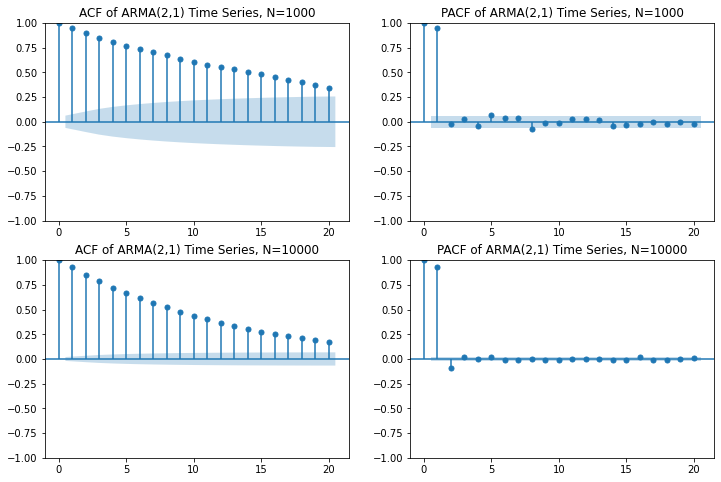

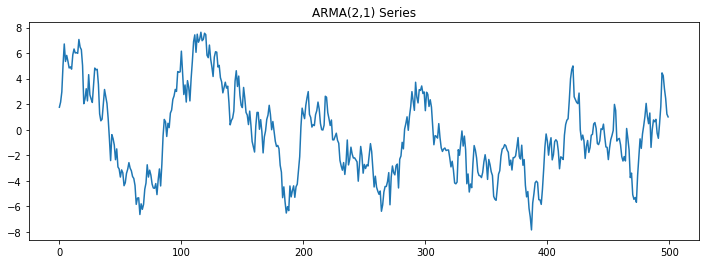

In [98]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm

# 设置随机种子以确保结果可重复
np.random.seed(0)

ar = np.array([1, -0.5,-0.4]) 
ma = np.array([1, 0.5])  
n = [int(1000),   int(10_000)] 

arma_process = sm.tsa.ArmaProcess(ar, ma)
y1 = arma_process.generate_sample(nsample=n[0])
y2 = arma_process.generate_sample(nsample=n[1])

fig, axes = plt.subplots(2, 2, figsize=(12, 8))  # 创建2行2列的子图

# 绘制ACF图像
plot_acf(y1, lags=20, ax=axes[0,0])
axes[0,0].set_title('ACF of ARMA(2,1) Time Series, N=1000')

# 绘制PACF图像
plot_pacf(y1, lags=20, ax=axes[0,1])
axes[0,1].set_title('PACF of ARMA(2,1) Time Series, N=1000')

# 绘制ACF图像
plot_acf(y2, lags=20, ax=axes[1,0])
axes[1,0].set_title('ACF of ARMA(2,1) Time Series, N=10000')

# 绘制PACF图像
plot_pacf(y2, lags=20, ax=axes[1,1])
axes[1,1].set_title('PACF of ARMA(2,1) Time Series, N=10000')
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(y1[:500])
plt.title('ARMA(2,1) Series')
plt.show()

ARMA(2,2) 模型的表达式为：
$$
(1-0.5L-0.4L^2)\cdot y_t= (1+0.5L+0.7L^2)\varepsilon_t\ \ \Rightarrow \ \ y_t=0.5y_{t-1}+0.4y_{t-2}+\varepsilon_t+0.5\varepsilon_{t-1}+0.7\varepsilon_{t-2}.
$$

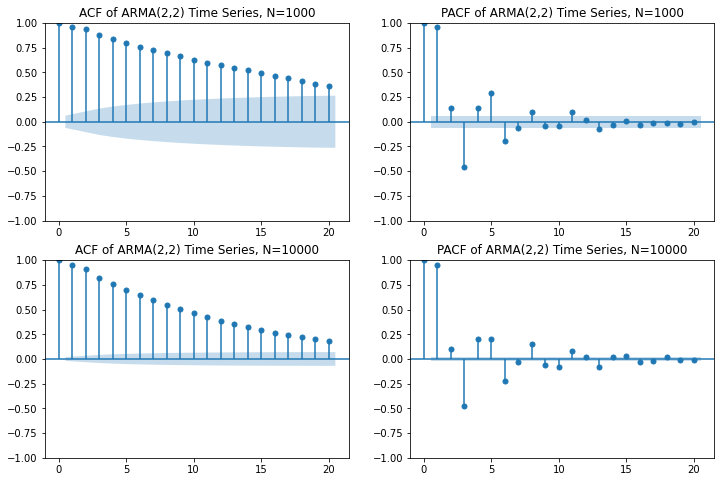

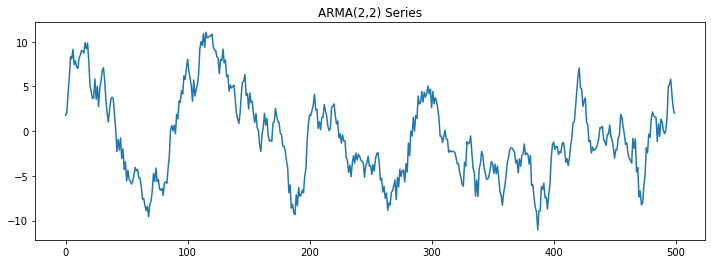

In [99]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm

# 设置随机种子以确保结果可重复
np.random.seed(0)

ar = np.array([1, -0.5,-0.4]) 
ma = np.array([1, 0.5,0.7])  
n = [int(1000),   int(10_000)] 

arma_process = sm.tsa.ArmaProcess(ar, ma)
y1 = arma_process.generate_sample(nsample=n[0])
y2 = arma_process.generate_sample(nsample=n[1])

fig, axes = plt.subplots(2, 2, figsize=(12, 8))  

# 绘制ACF图像
plot_acf(y1, lags=20, ax=axes[0,0])
axes[0,0].set_title('ACF of ARMA(2,2) Time Series, N=1000')

# 绘制PACF图像
plot_pacf(y1, lags=20, ax=axes[0,1])
axes[0,1].set_title('PACF of ARMA(2,2) Time Series, N=1000')

# 绘制ACF图像
plot_acf(y2, lags=20, ax=axes[1,0])
axes[1,0].set_title('ACF of ARMA(2,2) Time Series, N=10000')

# 绘制PACF图像
plot_pacf(y2, lags=20, ax=axes[1,1])
axes[1,1].set_title('PACF of ARMA(2,2) Time Series, N=10000')
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(y1[:500])
plt.title('ARMA(2,2) Series')
plt.show()

从理论上，ARMA(p,q)模型的ACF图与PACF图均是拖尾，但在某些情况（如ARMA(2,1)）下拖尾可能并不明显。

### 4.ARIMA 模型的 ACF 图与 PACF 图

ARIMA(1,1,1) 模型的表达式为：
$$
(1-0.5L) (1-L)y_t= (1+0.5L)\varepsilon_t\ \ \Rightarrow \ \ (1-L)y_t=0.5y_{t-1}+\varepsilon_t+0.5\varepsilon_{t-1}.
$$

ARIMA(1,2,1) 模型的表达式为：
$$
(1-0.5L) (1-L)^2y_t= (1+0.5L)\varepsilon_t\ \ \Rightarrow \ \ (1-L)^2y_t=0.5y_{t-1}+\varepsilon_t+0.5\varepsilon_{t-1}.
$$

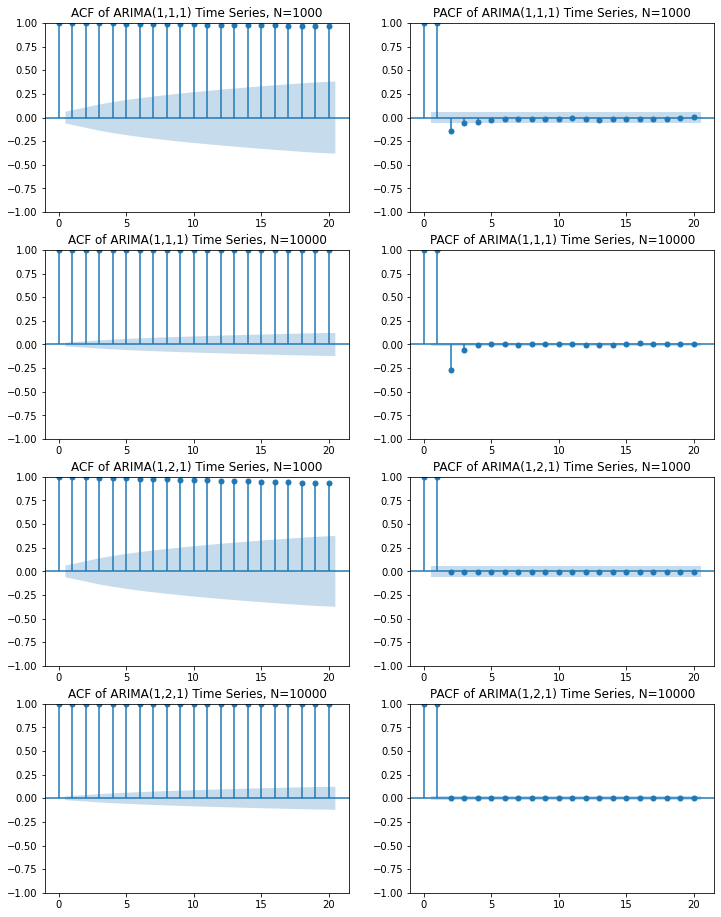

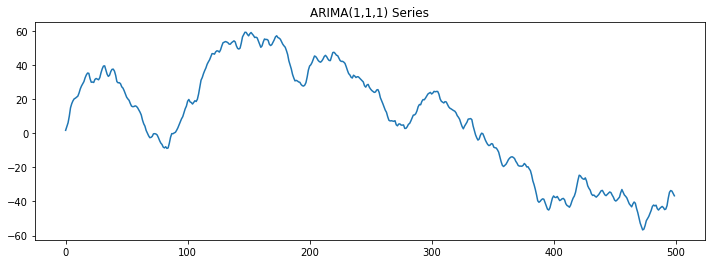

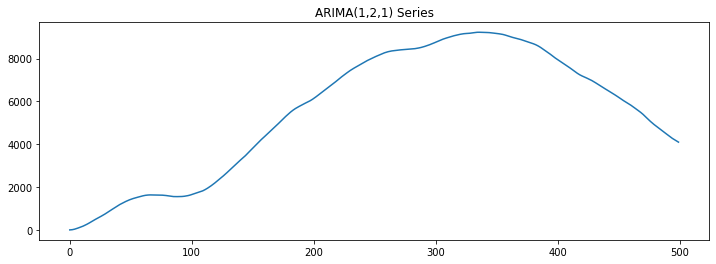

In [105]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm

# 设置随机种子以确保结果可重复
np.random.seed(0)

ar = np.array([1, -0.5]) 
ma = np.array([1, 0.5])  
d=1
n = [int(1000),   int(10_000)] 

# 生成长度为 n 的 ARMA 序列（这是差分后的序列 Δy_t）
arma_process = sm.tsa.ArmaProcess(ar, ma)
dy1 = arma_process.generate_sample(nsample=n[0])
dy2 = arma_process.generate_sample(nsample=n[1])

# 对 dy 进行 d 阶积分（cumsum），得到 ARIMA序列 y_t
y1= dy1.copy()
for _ in range(d):
     y1 = np.cumsum(y1)
        
y2= dy2.copy()
for _ in range(d):
     y2 = np.cumsum(y2)

fig, axes = plt.subplots(4, 2, figsize=(12, 16))

# 绘制ACF图像
plot_acf(y1, lags=20, ax=axes[0,0])
axes[0,0].set_title('ACF of ARIMA(1,1,1) Time Series, N=1000')

# 绘制PACF图像
plot_pacf(y1, lags=20, ax=axes[0,1])
axes[0,1].set_title('PACF of ARIMA(1,1,1) Time Series, N=1000')

# 绘制ACF图像
plot_acf(y2, lags=20, ax=axes[1,0])
axes[1,0].set_title('ACF of ARIMA(1,1,1) Time Series, N=10000')

# 绘制PACF图像
plot_pacf(y2, lags=20, ax=axes[1,1])
axes[1,1].set_title('PACF of ARIMA(1,1,1) Time Series, N=10000')

y1_1=y1
d=2

# 对 dy 进行 d 阶积分（cumsum），得到 ARIMA序列 y_t
y1= dy1.copy()
for _ in range(d):
     y1 = np.cumsum(y1)
        
y2= dy2.copy()
for _ in range(d):
     y2 = np.cumsum(y2)
        
# 绘制ACF图像
plot_acf(y1, lags=20, ax=axes[2,0])
axes[2,0].set_title('ACF of ARIMA(1,2,1) Time Series, N=1000')

# 绘制PACF图像
plot_pacf(y1, lags=20, ax=axes[2,1])
axes[2,1].set_title('PACF of ARIMA(1,2,1) Time Series, N=1000')

# 绘制ACF图像
plot_acf(y2, lags=20, ax=axes[3,0])
axes[3,0].set_title('ACF of ARIMA(1,2,1) Time Series, N=10000')

# 绘制PACF图像
plot_pacf(y2, lags=20, ax=axes[3,1])
axes[3,1].set_title('PACF of ARIMA(1,2,1) Time Series, N=10000')
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(y1_1[:500])
plt.title('ARIMA(1,1,1) Series')
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(y1[:500])
plt.title('ARIMA(1,2,1) Series')
plt.show()

ARIMA(1,1,2) 模型的表达式为：
$$
(1-0.5L)(1-L)y_t= (1+0.5L+0.7L^2)\varepsilon_t\ \ \Rightarrow \ \ (1-L)y_t=0.5y_{t-1}+\varepsilon_t+0.5\varepsilon_{t-1}+0.7\varepsilon_{t-2}.
$$

ARIMA(1,2,2) 模型的表达式为：
$$
(1-0.5L)(1-L)^2y_t= (1+0.5L+0.7L^2)\varepsilon_t\ \ \Rightarrow \ \ (1-L)^2y_t=0.5y_{t-1}+\varepsilon_t+0.5\varepsilon_{t-1}+0.7\varepsilon_{t-2}.
$$

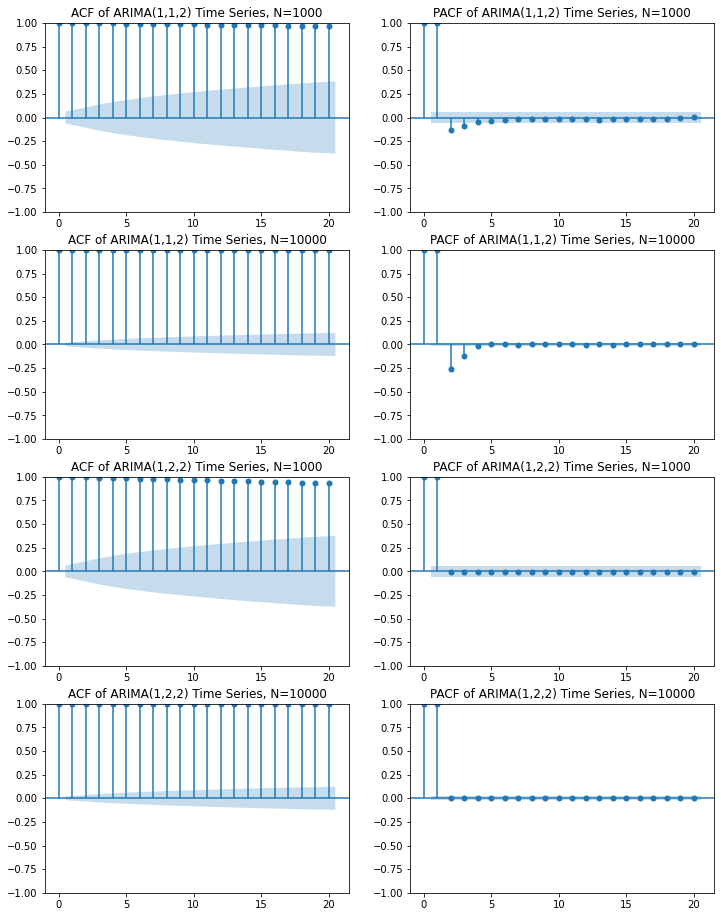

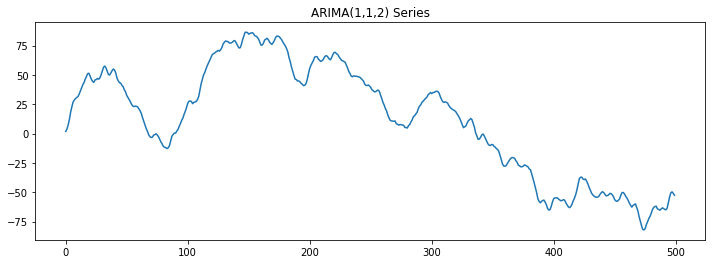

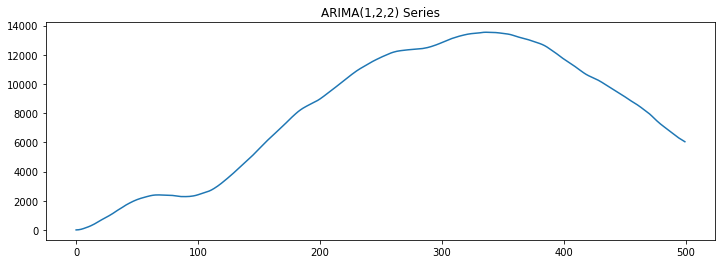

In [109]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm

# 设置随机种子以确保结果可重复
np.random.seed(0)

ar = np.array([1, -0.5]) 
ma = np.array([1, 0.5, 0.7])  
d=1
n = [int(1000),   int(10_000)] 

# 生成长度为 n 的 ARMA 序列（这是差分后的序列 Δy_t）
arma_process = sm.tsa.ArmaProcess(ar, ma)
dy1 = arma_process.generate_sample(nsample=n[0])
dy2 = arma_process.generate_sample(nsample=n[1])

# 对 dy 进行 d 阶积分（cumsum），得到 ARIMA序列 y_t
y1= dy1.copy()
for _ in range(d):
     y1 = np.cumsum(y1)
        
y2= dy2.copy()
for _ in range(d):
     y2 = np.cumsum(y2)

fig, axes = plt.subplots(4, 2, figsize=(12, 16))

# 绘制ACF图像
plot_acf(y1, lags=20, ax=axes[0,0])
axes[0,0].set_title('ACF of ARIMA(1,1,2) Time Series, N=1000')

# 绘制PACF图像
plot_pacf(y1, lags=20, ax=axes[0,1])
axes[0,1].set_title('PACF of ARIMA(1,1,2) Time Series, N=1000')

# 绘制ACF图像
plot_acf(y2, lags=20, ax=axes[1,0])
axes[1,0].set_title('ACF of ARIMA(1,1,2) Time Series, N=10000')

# 绘制PACF图像
plot_pacf(y2, lags=20, ax=axes[1,1])
axes[1,1].set_title('PACF of ARIMA(1,1,2) Time Series, N=10000')

y1_1=y1
d=2

# 对 dy 进行 d 阶积分（cumsum），得到 ARIMA序列 y_t
y1= dy1.copy()
for _ in range(d):
     y1 = np.cumsum(y1)
        
y2= dy2.copy()
for _ in range(d):
     y2 = np.cumsum(y2)
        
# 绘制ACF图像
plot_acf(y1, lags=20, ax=axes[2,0])
axes[2,0].set_title('ACF of ARIMA(1,2,2) Time Series, N=1000')

# 绘制PACF图像
plot_pacf(y1, lags=20, ax=axes[2,1])
axes[2,1].set_title('PACF of ARIMA(1,2,2) Time Series, N=1000')

# 绘制ACF图像
plot_acf(y2, lags=20, ax=axes[3,0])
axes[3,0].set_title('ACF of ARIMA(1,2,2) Time Series, N=10000')

# 绘制PACF图像
plot_pacf(y2, lags=20, ax=axes[3,1])
axes[3,1].set_title('PACF of ARIMA(1,2,2) Time Series, N=10000')
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(y1_1[:500])
plt.title('ARIMA(1,1,2) Series')
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(y1[:500])
plt.title('ARIMA(1,2,2) Series')
plt.show()

ARIMA(2,1,1) 模型的表达式为：
$$
(1-0.5L-0.4L^2)(1-L) y_t= (1+0.5L)\varepsilon_t\ \ \Rightarrow \ \ (1-L) y_t=0.5y_{t-1}+0.4y_{t-2}+\varepsilon_t+0.5\varepsilon_{t-1}.
$$

ARIMA(2,2,1) 模型的表达式为：
$$
(1-0.5L-0.4L^2)(1-L) ^2y_t= (1+0.5L)\varepsilon_t\ \ \Rightarrow \ \ (1-L) ^2y_t=0.5y_{t-1}+0.4y_{t-2}+\varepsilon_t+0.5\varepsilon_{t-1}.
$$

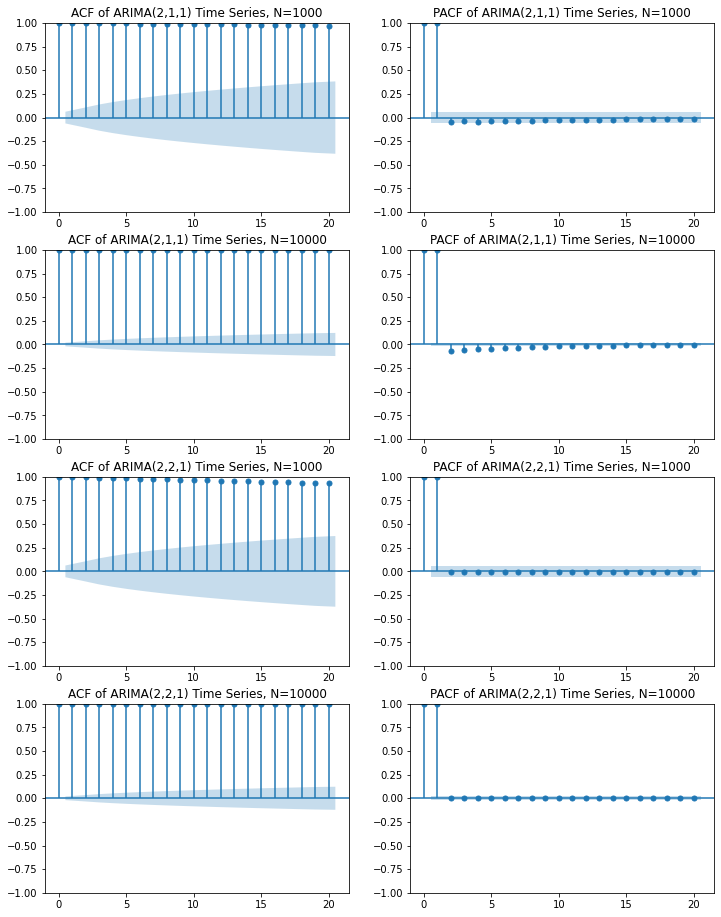

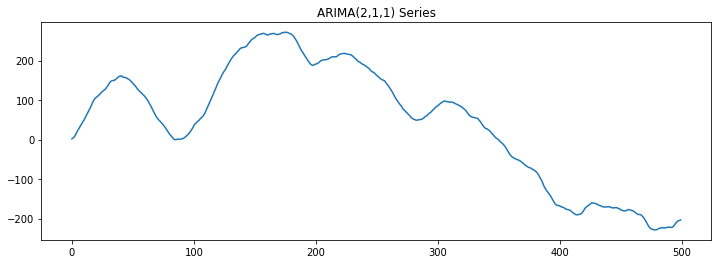

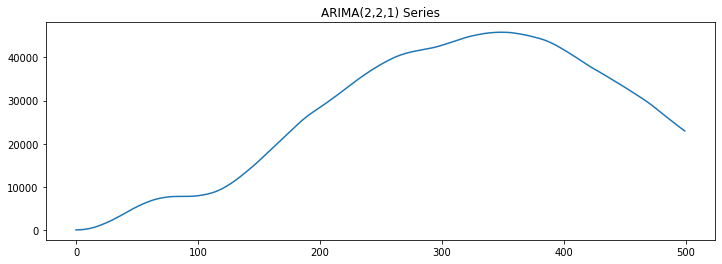

In [108]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm

# 设置随机种子以确保结果可重复
np.random.seed(0)

ar = np.array([1, -0.5, -0.4]) 
ma = np.array([1, 0.5])  
d=1
n = [int(1000),   int(10_000)] 

# 生成长度为 n 的 ARMA 序列（这是差分后的序列 Δy_t）
arma_process = sm.tsa.ArmaProcess(ar, ma)
dy1 = arma_process.generate_sample(nsample=n[0])
dy2 = arma_process.generate_sample(nsample=n[1])

# 对 dy 进行 d 阶积分（cumsum），得到 ARIMA序列 y_t
y1= dy1.copy()
for _ in range(d):
     y1 = np.cumsum(y1)
        
y2= dy2.copy()
for _ in range(d):
     y2 = np.cumsum(y2)

fig, axes = plt.subplots(4, 2, figsize=(12, 16))

# 绘制ACF图像
plot_acf(y1, lags=20, ax=axes[0,0])
axes[0,0].set_title('ACF of ARIMA(2,1,1) Time Series, N=1000')

# 绘制PACF图像
plot_pacf(y1, lags=20, ax=axes[0,1])
axes[0,1].set_title('PACF of ARIMA(2,1,1) Time Series, N=1000')

# 绘制ACF图像
plot_acf(y2, lags=20, ax=axes[1,0])
axes[1,0].set_title('ACF of ARIMA(2,1,1) Time Series, N=10000')

# 绘制PACF图像
plot_pacf(y2, lags=20, ax=axes[1,1])
axes[1,1].set_title('PACF of ARIMA(2,1,1) Time Series, N=10000')

y1_1=y1
d=2

# 对 dy 进行 d 阶积分（cumsum），得到 ARIMA序列 y_t
y1= dy1.copy()
for _ in range(d):
     y1 = np.cumsum(y1)
        
y2= dy2.copy()
for _ in range(d):
     y2 = np.cumsum(y2)
        
# 绘制ACF图像
plot_acf(y1, lags=20, ax=axes[2,0])
axes[2,0].set_title('ACF of ARIMA(2,2,1) Time Series, N=1000')

# 绘制PACF图像
plot_pacf(y1, lags=20, ax=axes[2,1])
axes[2,1].set_title('PACF of ARIMA(2,2,1) Time Series, N=1000')

# 绘制ACF图像
plot_acf(y2, lags=20, ax=axes[3,0])
axes[3,0].set_title('ACF of ARIMA(2,2,1) Time Series, N=10000')

# 绘制PACF图像
plot_pacf(y2, lags=20, ax=axes[3,1])
axes[3,1].set_title('PACF of ARIMA(2,2,1) Time Series, N=10000')
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(y1_1[:500])
plt.title('ARIMA(2,1,1) Series')
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(y1[:500])
plt.title('ARIMA(2,2,1) Series')
plt.show()

ARIMA(2,1,2) 模型的表达式为：
$$
(1-0.5L-0.4L^2)(1-L) y_t= (1+0.5L+0.7L^2)\varepsilon_t\ \ \Rightarrow \ \ (1-L) y_t=0.5y_{t-1}+0.4y_{t-2}+\varepsilon_t+0.5\varepsilon_{t-1}+0.7\varepsilon_{t-2}.
$$

ARIMA(2,2,2) 模型的表达式为：
$$
(1-0.5L-0.4L^2)(1-L) ^2y_t= (1+0.5L+0.7L^2)\varepsilon_t\ \ \Rightarrow \ \ (1-L)^2 y_t=0.5y_{t-1}+0.4y_{t-2}+\varepsilon_t+0.5\varepsilon_{t-1}+0.7\varepsilon_{t-2}.
$$

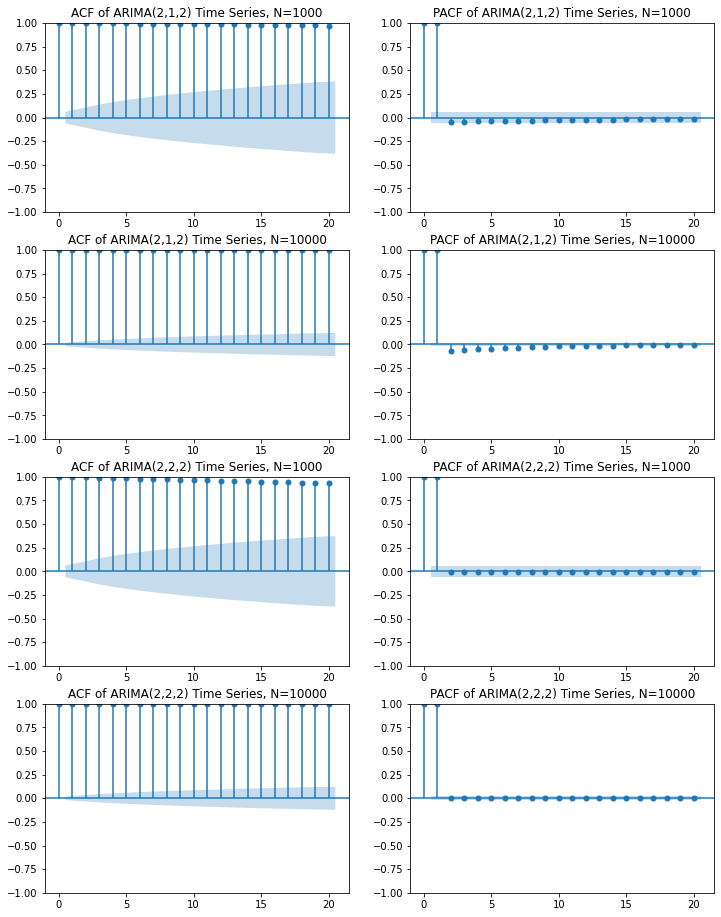

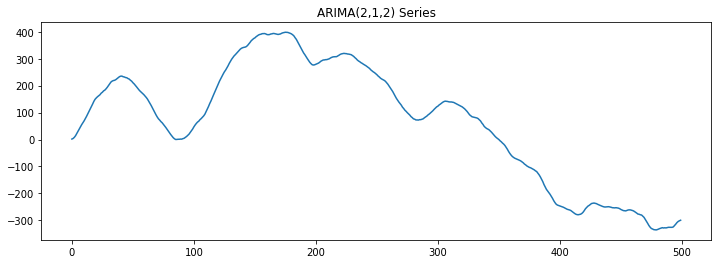

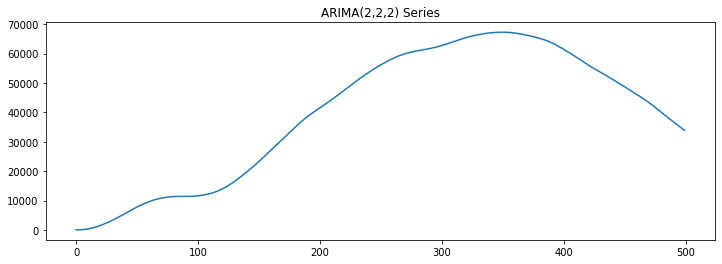

In [112]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm

# 设置随机种子以确保结果可重复
np.random.seed(0)

ar = np.array([1, -0.5, -0.4]) 
ma = np.array([1, 0.5, 0.7])  
d=1
n = [int(1000),   int(10_000)] 

# 生成长度为 n 的 ARMA 序列（这是差分后的序列 Δy_t）
arma_process = sm.tsa.ArmaProcess(ar, ma)
dy1 = arma_process.generate_sample(nsample=n[0])
dy2 = arma_process.generate_sample(nsample=n[1])

# 对 dy 进行 d 阶积分（cumsum），得到 ARIMA序列 y_t
y1= dy1.copy()
for _ in range(d):
     y1 = np.cumsum(y1)
        
y2= dy2.copy()
for _ in range(d):
     y2 = np.cumsum(y2)

fig, axes = plt.subplots(4, 2, figsize=(12, 16))

# 绘制ACF图像
plot_acf(y1, lags=20, ax=axes[0,0])
axes[0,0].set_title('ACF of ARIMA(2,1,2) Time Series, N=1000')

# 绘制PACF图像
plot_pacf(y1, lags=20, ax=axes[0,1])
axes[0,1].set_title('PACF of ARIMA(2,1,2) Time Series, N=1000')

# 绘制ACF图像
plot_acf(y2, lags=20, ax=axes[1,0])
axes[1,0].set_title('ACF of ARIMA(2,1,2) Time Series, N=10000')

# 绘制PACF图像
plot_pacf(y2, lags=20, ax=axes[1,1])
axes[1,1].set_title('PACF of ARIMA(2,1,2) Time Series, N=10000')

y1_1=y1
d=2

# 对 dy 进行 d 阶积分（cumsum），得到 ARIMA序列 y_t
y1= dy1.copy()
for _ in range(d):
     y1 = np.cumsum(y1)
        
y2= dy2.copy()
for _ in range(d):
     y2 = np.cumsum(y2)
        
# 绘制ACF图像
plot_acf(y1, lags=20, ax=axes[2,0])
axes[2,0].set_title('ACF of ARIMA(2,2,2) Time Series, N=1000')

# 绘制PACF图像
plot_pacf(y1, lags=20, ax=axes[2,1])
axes[2,1].set_title('PACF of ARIMA(2,2,2) Time Series, N=1000')

# 绘制ACF图像
plot_acf(y2, lags=20, ax=axes[3,0])
axes[3,0].set_title('ACF of ARIMA(2,2,2) Time Series, N=10000')

# 绘制PACF图像
plot_pacf(y2, lags=20, ax=axes[3,1])
axes[3,1].set_title('PACF of ARIMA(2,2,2) Time Series, N=10000')
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(y1_1[:500])
plt.title('ARIMA(2,1,2) Series')
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(y1[:500])
plt.title('ARIMA(2,2,2) Series')
plt.show()

由上，ARIMA(p,d,q)模型在 p≠0，d≠0，q≠0的情况下生成的序列对应的ACF与PACF图特性相同，即ACF图极其缓慢衰减，而PACF图则呈现1阶截尾。

### 4. 白噪声的 ACF 图与 PACF 图

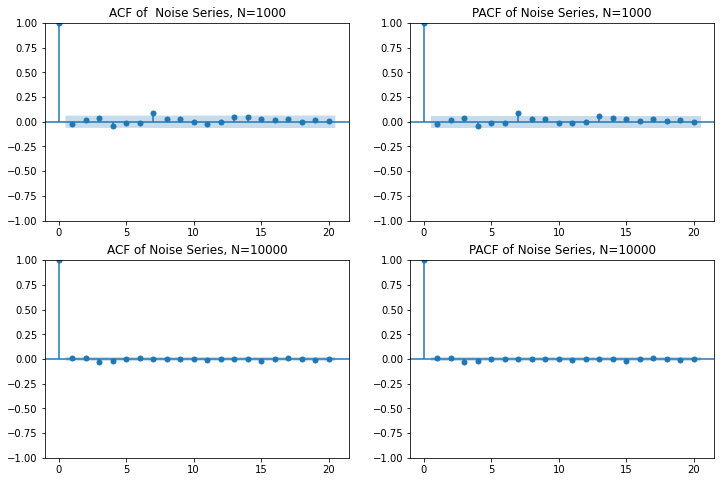

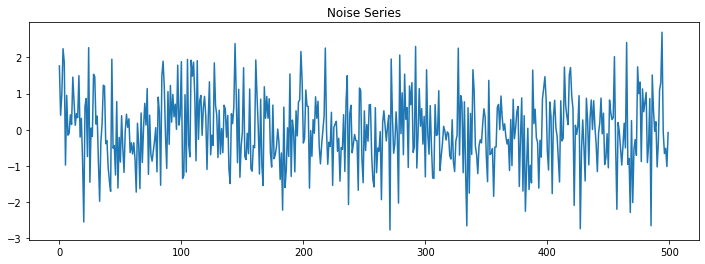

In [117]:
import numpy as np
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

np.random.seed(0)
sample1 = np.random.normal(size=1000)
sample2 = np.random.normal(size=10000)

# 绘制ACF和PACF图
plt.figure(figsize=(12,8))
plt.subplot(221)
plot_acf(sample1, ax=plt.gca(), lags=20)
plt.title('ACF of  Noise Series, N=1000')
plt.subplot(222)
plot_pacf(sample1, ax=plt.gca(), lags=20)
plt.title('PACF of Noise Series, N=1000')
plt.subplot(223)
plot_acf(sample2, ax=plt.gca(), lags=20)
plt.title('ACF of Noise Series, N=10000')
plt.subplot(224)
plot_pacf(sample2, ax=plt.gca(), lags=20)
plt.title('PACF of Noise Series, N=10000')
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(sample1[:500])
plt.title('Noise Series')
plt.show()

白噪声的ACF图和PACF图除滞后为0项外，几乎没有显著的值。